In [2]:
import numpy as np
import pandas as pd
import os, sys, glob
%load_ext autoreload
%autoreload 2
import RM_utils as utils
import nibabel as nib
from config import *
from nibabel import Nifti1Image
from scipy import stats
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import matplotlib.pyplot as plt
import scprep, tphate, phate
from nilearn import plotting
import shutil
import seaborn as sns
from brainiak.searchlight.searchlight import Searchlight
from camcan_utils import get_brain_cmap
import skdim
import camcan_utils
import narratives_utils
import statsmodels.api as sm
import ide_helpers as ide
import task_comparison as tc
from nilearn.image import math_img

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
0.9 * 22

19.8

(array([5075., 2159., 1864., 1914., 1674., 1612., 1594., 1703., 1388.,
         559.]),
 array([ 1. ,  2.9,  4.8,  6.7,  8.6, 10.5, 12.4, 14.3, 16.2, 18.1, 20. ]),
 <BarContainer object of 10 artists>)

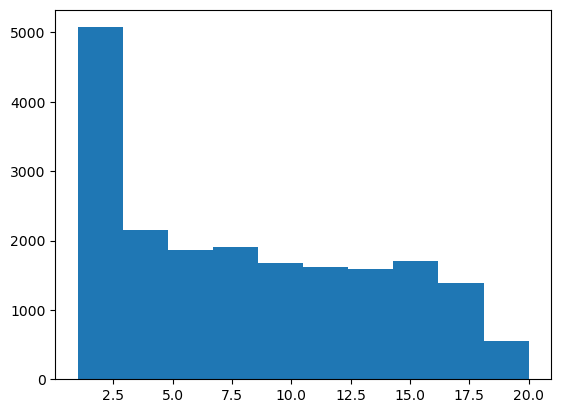

In [68]:
plt.hist(summed[summed!=0])

0.31164445357162907 (70958,) 1165 0.016418162856901265


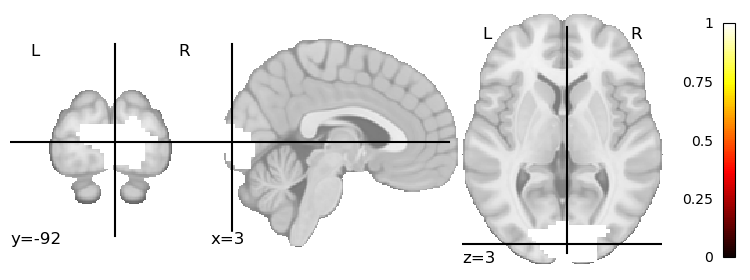

In [106]:
# determine selective voxels
rm_mask = utils.get_intersect_mask()
rm_isc_fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/ISC/*ISC_all_subjects_results.npy'))[:2] # only take movies
data = np.vstack([np.load(f) for f in rm_isc_fns])
# # find the top 5 percent
q=np.percentile(data, 90)
bindata = np.where(data > q, 1, 0)
summed = np.sum(bindata, axis=0)
mask = np.where(summed >= 18, 1, 0)
print(q, summed.shape, np.sum(mask), np.sum(mask)/summed.shape[0])
brain_mask_ISC = tc.vec2vol(mask, rm_mask)
plotting.plot_stat_map(brain_mask_ISC)
nib.save(brain_mask_ISC,'masks/RestMovie_isc_mask_v2.nii.gz')

In [30]:
nonsel_masker = NiftiMasker(rm_isc_mask_opp,standardize=False)
avg_aero = nib.load('RestMovie/results/result_volumes/aeronaut_tphate_optt_knn20_smooth_window1_average_result.nii.gz')
avg_mick = nib.load('RestMovie/results/result_volumes/mickey_tphate_optt_knn20_smooth_window1_average_result.nii.gz')
avg_rest = nib.load('RestMovie/results/result_volumes/rest_tphate_optt_knn20_smooth_window1_average_result.nii.gz')
rest_nonsel = np.squeeze(nonsel_masker.fit_transform(avg_rest))
mick_nonsel = np.squeeze(nonsel_masker.fit_transform(avg_mick))
aero_nonsel = np.squeeze(nonsel_masker.fit_transform(avg_aero))



In [31]:
rest_nonsel.shape

(58438,)

In [70]:
# rm_isc_mask = nib.load('masks/RestMovie_isc_mask.nii.gz')
sel_masker = NiftiMasker(brain_mask_ISC,standardize=False)
rest_sel = np.squeeze(sel_masker.fit_transform(avg_rest))
mick_sel = np.squeeze(sel_masker.fit_transform(avg_mick))
aero_sel = np.squeeze(sel_masker.fit_transform(avg_aero))


In [84]:
def load_mask_data_file(mask_coords, subject, task, metric, filter_by_age=0, slrad=5):
    nii = utils.get_metric_nii_subject(subject, task, metric, filter_by_age=filter_by_age, slrad=slrad)
    x = nii.get_fdata()
    vec = x[mask_coords[0][:], mask_coords[1][:], mask_coords[2][:]]
    return vec

In [88]:
np.sum(brain_mask_ISC.get_fdata())

2764.0

In [107]:
sel_voxels = np.where(brain_mask_ISC.get_fdata() == 1)
mick_d = np.zeros((11, int(np.sum(brain_mask_ISC.get_fdata()))))
aero_d = np.zeros_like(mick_d) 
rest_d= np.zeros_like(mick_d) 
for s,sub in enumerate(RM_SUBJECTS):
    aero_d[s] = (load_mask_data_file(sel_voxels, sub, 'aeronaut', 'tphate_optt_knn20_smooth_window1'))
    mick_d[s] = (load_mask_data_file(sel_voxels, sub, 'mickey', 'tphate_optt_knn20_smooth_window1'))
    rest_d[s] = (load_mask_data_file(sel_voxels, sub, 'rest', 'tphate_optt_knn20_smooth_window1'))


In [116]:
stats.spearmanr(np.mean(mick_d,axis=0),np.mean(rest_d,axis=0)), stats.spearmanr(np.mean(aero_d,axis=0),np.mean(rest_d,axis=0)), 

(SpearmanrResult(correlation=0.1415467069134084, pvalue=1.231255026137827e-06),
 SpearmanrResult(correlation=-0.35003300188656145, pvalue=6.514366640125323e-35))

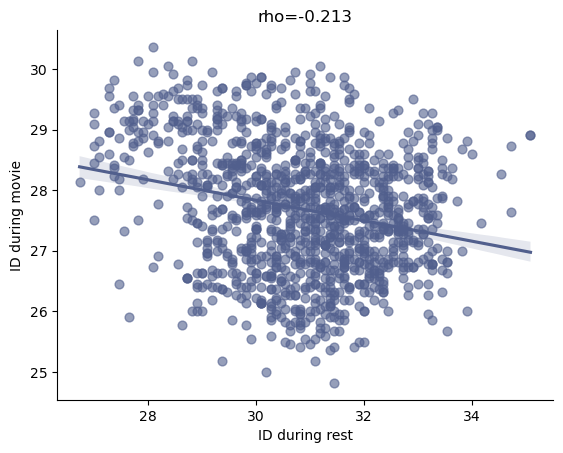

In [136]:
avg_movie = np.mean(np.mean([mick_d,aero_d],axis=0),axis=0)
avg_rest = np.mean(rest_d,axis=0)
fig,ax=plt.subplots(1)
df2 = pd.DataFrame({'rest_sel_avg_ide':avg_rest, 'mick_sel_avg_ide':np.mean(mick_d,axis=0), 
                    'aero_sel_avg_ide':np.mean(aero_d,axis=0), 'avg_movie':avg_movie})

# g = sns.regplot(data=df2, x='rest_sel_avg_ide', y='mick_sel_avg_ide',  color='gray', order=1, scatter_kws={'alpha':0.1, 's':1}, ax=ax[0])
# r,p = stats.spearmanr(df2['rest_sel_avg_ide'],df2['mick_sel_avg_ide'])
# g.set( xlabel='ID at rest', ylabel='ID watching Mickey', title=f'rho={np.round(r, 3)}')

# g = sns.regplot(data=df2, x='rest_sel_avg_ide', y='aero_sel_avg_ide',color='gray', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[1])
# r,p = stats.spearmanr(df2['rest_sel_avg_ide'],df2['aero_sel_avg_ide'])
# g.set( xlabel='ID at rest', ylabel='ID watching Aeronaut', title=f'rho={np.round(r, 3)}')

g = sns.regplot(data=df2, x='rest_sel_avg_ide', y='avg_movie', color='#515F8D', order=1, 
                scatter_kws={'alpha':0.6, 's':40}, ax=ax)
r,p = stats.spearmanr(df2['rest_sel_avg_ide'],df2['avg_movie'])
g.set( xlabel='ID during rest', ylabel='ID during movie', title=f'rho={np.round(r, 3)}')


sns.despine()
plt.savefig('ccn_plots/ISC_voxel_corrs.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [133]:
r,p

(-0.2126218182266284, 2.2430780533678321e-13)

In [ ]:
sns.regplot( x=)

In [113]:
np.mean([stats.pearsonr(rest_d[i], aero_d[i])[0] for i in range(11)]), np.mean([stats.pearsonr(rest_d[i], mick_d[i])[0] for i in range(11)]), 

(-0.042597126743968504, 0.18486144908528546)

<AxesSubplot:>

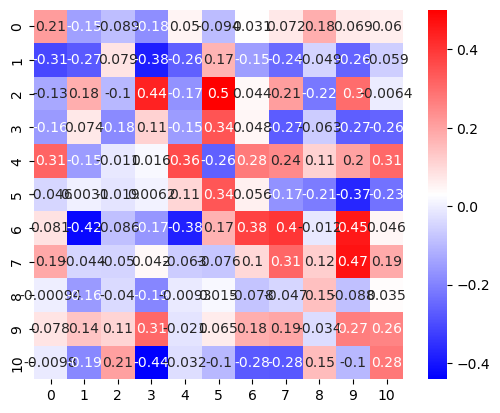

In [115]:
sns.heatmap(1-cdist(mick_d, rest_d, 'correlation'), cmap='bwr',square=True, annot=True)

In [112]:
stats.pearsonr(rest_sel, mick_sel),stats.pearsonr(rest_sel, aero_sel) 

((0.06296186078845757, 0.0009265456048146442),
 (-0.15778701373458534, 7.180535222116406e-17))

In [21]:
rm_isc_mask = nib.load('masks/RestMovie_isc_mask_v2.nii.gz')
#invert
rm_isc_mask_opp = math_img('np.where(img != 0, 0, 1)', img=brain_mask_ISC)
rm_mask = nib.load('masks/AERONAUT_MICKEY_REST_intersect_mask.nii.gz')
masker_wb =  NiftiMasker(rm_mask)
rm_isc_mask_opp = masker_wb.fit_transform(rm_isc_mask_opp)
rm_isc_mask_opp = masker_wb.inverse_transform(rm_isc_mask_opp)
# rm_isc_mask_opp = math_img('img1*img2',img1=rm_mask,img2=rm_isc_mask_opp)


(<Figure size 768x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

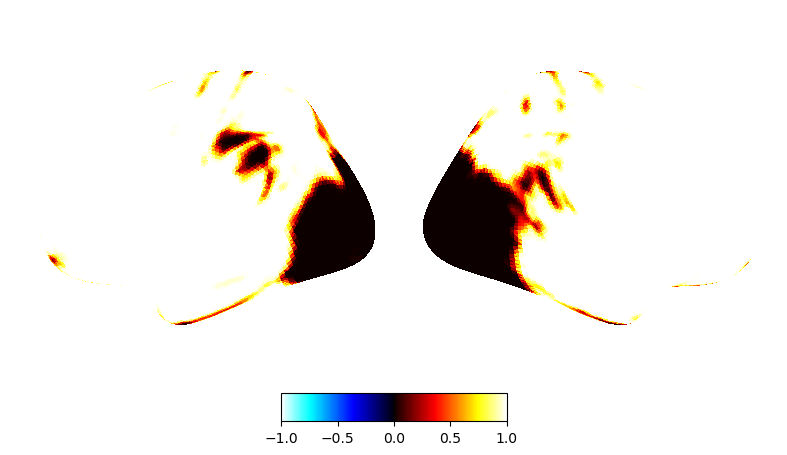

In [22]:
plotting.plot_img_on_surf(rm_isc_mask_opp, 
                                  views=['lateral'], 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  darkness=0.8, 
                                  threshold=0,
                              vmax=1,
                                 )

# plot subject average IDE difference results

In [ ]:
dataset = 'rest_movie'
tasks = ['MICKEY','AERONAUT','REST']
all_subjects = RM_SUBJECTS
metrics = ['lPCA','FisherS', 'MLE', 'MiND_ML', 'DIFF_MAP_SE','TPHATE_SE','optt']
for m in metrics:
    

# plot subject average IDE results

In [39]:
df = pd.DataFrame(columns = ['dataset','metric','task','subject', 'average_score', 'std_score'])

for dataset, tasks in zip(['camcan','rest_movie'],[CAMCAN_TASKS, RM_DATA_DIRS.keys()]):
    dataset = 'camcan'
    tasks = CAMCAN_TASKS
    all_subjects = camcan_utils.get_intersecting_subjects(35)
    for meth in ide.METHOD_NAMES + ['optt']:
        for t in ['movie','rest','SMT']:
            # load in all the results
            if meth == 'optt': fn = f'{camcan_utils.get_results_dir()}/aggregated_npy/{t.upper()}_tphate_{meth}_all_subjects_results.npy'
            else: fn = f'{camcan_utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
            dall = np.load(fn)
            dmean = np.nanmean(dall, axis=1) # average across brain, within subject
            dstd = np.nanstd(dall, axis=1)
            # average the other way to get the maximum across brain averaged across subs
            N = len(dmean)
            df = pd.concat([df, pd.DataFrame({'dataset':np.repeat(dataset,N), 'metric':np.repeat(meth,N), 
                               'task':np.repeat(t.lower(),N), 'subject':all_subjects, 
                               'average_score':dmean, 'std_score': dstd, })])
print(dataset)
        
        
dataset = 'rest_movie'
tasks = ['MICKEY','AERONAUT','REST']
all_subjects = RM_SUBJECTS
for meth in ide.METHOD_NAMES + ['optt']:
    for t in  tasks:
        # load in all the results
        if meth == 'optt': fn = f'{utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        else: fn = f'{utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        dall = np.load(fn)
        dmean = np.nanmean(dall, axis=1) # average across brain, within subject
        dstd = np.nanstd(dall, axis=1)
        N = len(dmean)
        df = pd.concat([df, pd.DataFrame({'dataset':np.repeat(dataset,N), 'metric':np.repeat(meth,N), 
                           'task':np.repeat(t.lower(),N), 'subject':all_subjects, 
                           'average_score':dmean, 'std_score': dstd})])
print(dataset)
        
dataset = 'narratives'
tasks = list(NARRATIVES_DATA_DIRS.keys())
for meth in ['']ide.METHOD_NAMES + ['optt']:
    for t in  tasks:
        # load in all the results
        if meth == 'optt': fn = f'{narratives_utils.get_results_dir()}/aggregated_npy/{t.upper()}_tphate_{meth}_all_subjects_results.npy'
        else: fn = f'{narratives_utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        dall = np.load(fn)
        dmean = np.nanmean(dall, axis=1) # average across brain, within subject
        dstd = np.nanstd(dall, axis=1)
        N = len(dmean)
        df = pd.concat([df, pd.DataFrame({'dataset':np.repeat(dataset,N), 'metric':np.repeat(meth,N), 
                           'task':np.repeat(t.lower(),N), 'subject':np.arange(len(dall)), 
                           'average_score':dmean, 'std_score': dstd})])
print(dataset)
df.to_csv('cross_dataset_results/subject_average_IDE_scores.csv')

camcan
rest_movie
narratives


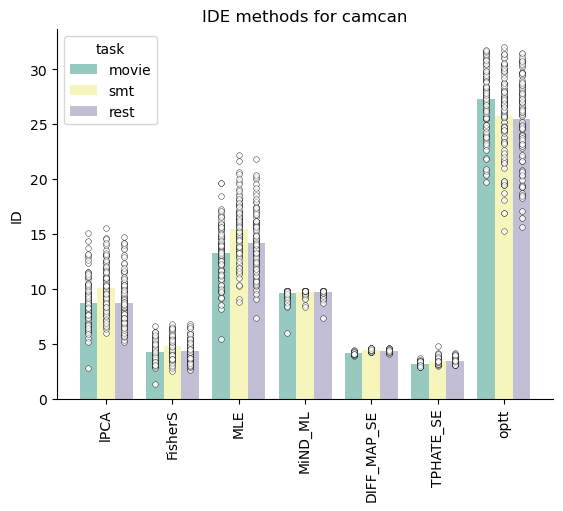

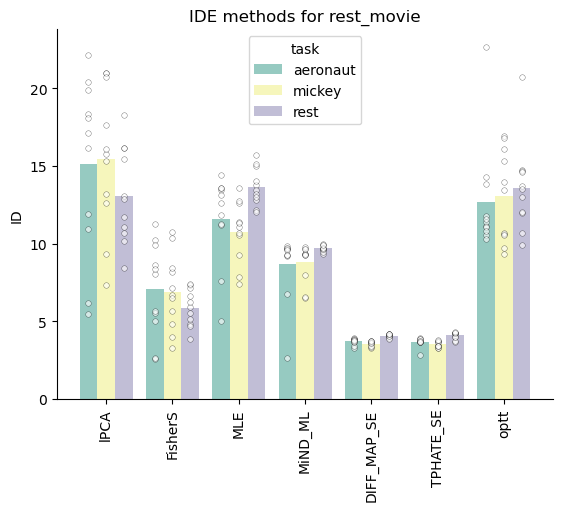

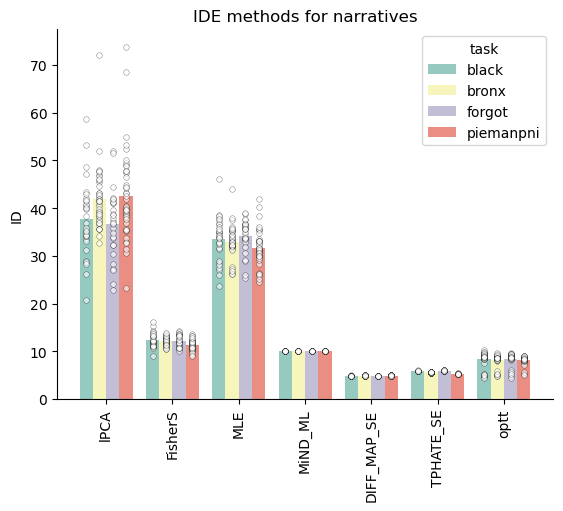

In [60]:
ordering = {'camcan':['movie','smt','rest'], 'rest_movie':['aeronaut','mickey','rest'], 'narratives':['black','bronx','forgot','piemanpni']}
xorder = ['lPCA', 'FisherS', 'MLE', 'MiND_ML',  'TPHATE_SE', 'optt']
for k,v in ordering.items():
    
    subdf = df[df['dataset'] == k]
    fig,ax=plt.subplots()
    g = sns.barplot(data=subdf, hue='task', ci=None, hue_order=v, x='metric', y='average_score', order=xorder, ax=ax, palette='Set3')
    plt.xticks(rotation=90)
    g.set(xlabel='', title=f'IDE methods for {k}', ylabel='ID')
    
    for container, task in zip(g.containers, v):    
        for c, patch in enumerate(container):
            w = patch.get_width()/2
            x, y = patch.xy
            meth = xorder[c] 
            points = subdf[(subdf['metric']==meth) & (subdf['task']==task)]['average_score'].values

            ax.scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=0.6,
                       zorder=10, linewidths=0.3, s=16, c="white")
    
    
    sns.despine()


In [66]:
df = pd.DataFrame(columns = ['dataset','metric','task','mean_score', 'std_score', 'max_score', 'min_score'])

for dataset, tasks in zip(['camcan','rest_movie'],[CAMCAN_TASKS, RM_DATA_DIRS.keys()]):
    dataset = 'camcan'
    tasks = CAMCAN_TASKS
    all_subjects = camcan_utils.get_intersecting_subjects(35)
    for meth in ide.METHOD_NAMES + ['optt']:
        for t in ['movie','rest','SMT']:
            # load in all the results
            if meth == 'optt': fn = f'{camcan_utils.get_results_dir()}/aggregated_npy/{t.upper()}_tphate_{meth}_all_subjects_results.npy'
            else: fn = f'{camcan_utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
            dall = np.load(fn)
            avg_brain = np.mean(dall, axis=0)
            # average across the brain
            avg = np.mean(avg_brain)
            # min and max
            minn,maxx,stdd = np.min(avg_brain), np.max(avg_brain), np.nanstd(avg_brain)
            df.loc[len(df)] = {'dataset':dataset,
                               'metric':meth,
                               'task':t,
                               'mean_score':avg, 
                               'std_score':stdd, 'max_score':maxx,
                               'min_score':minn}
            
print(dataset)
        
        
dataset = 'rest_movie'
tasks = ['MICKEY','AERONAUT','REST']
all_subjects = RM_SUBJECTS
for meth in ide.METHOD_NAMES + ['optt']:
    for t in  tasks:
        # load in all the results
        if meth == 'optt': fn = f'{utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        else: fn = f'{utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        dall = np.load(fn)
        avg_brain = np.mean(dall, axis=0)
        # average across the brain
        avg = np.mean(avg_brain)
        # min and max
        minn,maxx,stdd = np.min(avg_brain), np.max(avg_brain), np.nanstd(avg_brain)
        df.loc[len(df)] = {'dataset':dataset,
                           'metric':meth,
                           'task':t,
                           'mean_score':avg, 
                           'std_score':stdd, 'max_score':maxx,
                           'min_score':minn}
print(dataset)
        
dataset = 'narratives'
tasks = list(NARRATIVES_DATA_DIRS.keys())
for meth in ide.METHOD_NAMES + ['optt']:
    for t in  tasks:
        # load in all the results
        if meth == 'optt': fn = f'{narratives_utils.get_results_dir()}/aggregated_npy/{t.upper()}_tphate_{meth}_all_subjects_results.npy'
        else: fn = f'{narratives_utils.get_results_dir()}/aggregated_npy/{t.upper()}_{meth}_all_subjects_results.npy'
        dall = np.load(fn)
        avg_brain = np.mean(dall, axis=0)
        # average across the brain
        avg = np.mean(avg_brain)
        # min and max
        minn,maxx,stdd = np.min(avg_brain), np.max(avg_brain), np.nanstd(avg_brain)
        df.loc[len(df)] = {'dataset':dataset,
                           'metric':meth,
                           'task':t,
                           'mean_score':avg, 
                           'std_score':stdd, 
                           'max_score':maxx,
                           'min_score':minn}
print(dataset)
df.to_csv('cross_dataset_results/average_brain_IDE_scores.csv')

camcan
rest_movie
narratives


In [70]:
nii = nib.load('./RestMovie/results/aggregated_nii/REST_MICKEY_optt_mean_difference_SL_rad5.nii.gz')

In [98]:
!pwd

/gpfs/milgram/pi/turk-browne/users/elb77/task_dim


In [ ]:
nii = nib.load()

(<Figure size 768x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

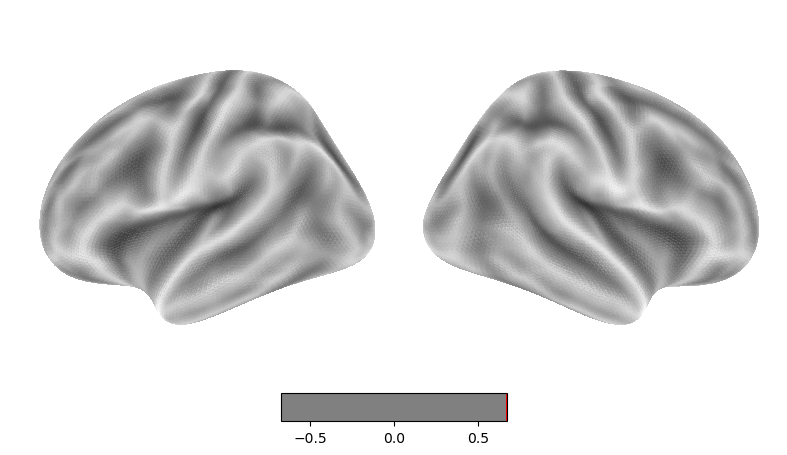

In [99]:
nii = nib.load('./CamCAN/results/MOVIE_REST_TPHATE_SE_mean_difference_SL_rad5.nii.gz')
plotting.plot_img_on_surf(nii, 
                          views=['lateral'], 
                          cmap='bwr', 
                          inflate=True, 
                          bg_on_data=False, 
                                  alpha=0.8,
                          darkness=0.8, threshold=1
                         )

(<Figure size 426.667x480 with 5 Axes>,
 [<Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <AxesSubplot:>])

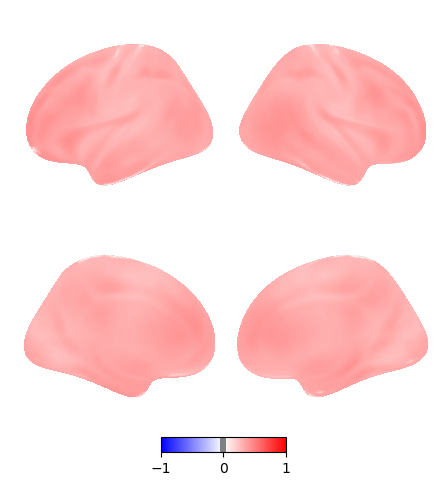

In [81]:
nii = nib.load('./RestMovie/results/aggregated_nii/REST_AERONAUT_DIFF_MAP_SE_mean_difference_SL_rad5.nii.gz')
plotting.plot_img_on_surf(nii, 
                          views=['lateral','medial'], 
                          cmap='bwr', 
                          inflate=True, 
                          bg_on_data=False, 
                                  alpha=0.8,
                          darkness=0.8, threshold=0.05, vmax=1
                         )

(<Figure size 426.667x480 with 5 Axes>,
 [<Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <Axes3DSubplot:>,
  <AxesSubplot:>])

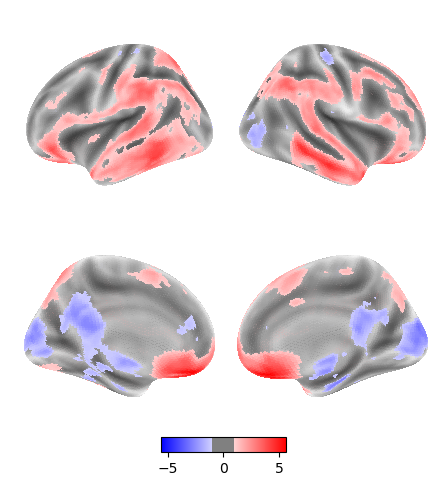

In [74]:
nii = nib.load('./RestMovie/results/aggregated_nii/REST_MICKEY_optt_mean_difference_SL_rad5.nii.gz')
plotting.plot_img_on_surf(nii, 
                          views=['lateral','medial'], 
                          cmap='bwr', 
                          inflate=True, 
                          bg_on_data=False, 
                                  alpha=0.8,
                          darkness=0.8, threshold=1
                         )

In [67]:
def load_avg_map(dataset, task, metric)

,dataset,metric,task,mean_score,std_score,max_score,min_score
0,camcan,CorrInt,movie,9.639560,2.675011,17.127556,0.000000
1,camcan,CorrInt,rest,10.520479,3.005382,19.999007,0.000000
2,camcan,CorrInt,SMT,11.259838,3.451542,22.678946,0.000000
3,camcan,DIFF_MAP_SE,movie,4.171352,0.529956,4.525923,0.000000
4,camcan,DIFF_MAP_SE,rest,4.358372,0.554581,4.728801,0.000000
...,...,...,...,...,...,...,...
125,narratives,lPCA,FORGOT,36.602558,26.895916,153.428571,6.535714
126,narratives,optt,BLACK,8.312479,1.058075,12.090909,6.909091
127,narratives,optt,PIEMANPNI,8.156765,0.996851,11.444444,6.711111
128,narratives,optt,BRONX,8.177153,0.988817,11.911111,6.866667
